<a href="https://colab.research.google.com/github/IrineuBovoJunior398/Pos-em-IA/blob/main/EXERC%C3%8DCIO_TDNN_IMPLEMENTA%C3%87%C3%83O_COM_MLPRegressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# EXERCÍCIO TDNN - Time Delay Neural Network
# Implementação com MLPRegressor (sklearn)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')








Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 1. CARREGAMENTO E PREPARAÇÃO DOS DADOS


# Série temporal completa (t=1 a t=120)
ft = [
    0.1701, 0.1023, 0.4405, 0.3609, 0.7192, 0.2258, 0.3175, 0.0127, 0.4290, 0.0544,
    0.8000, 0.0450, 0.4268, 0.0112, 0.3218, 0.2185, 0.7240, 0.3516, 0.4420, 0.0984,
    0.1747, 0.3964, 0.5114, 0.6183, 0.3330, 0.2398, 0.0508, 0.4497, 0.2178, 0.7762,
    0.1078, 0.3773, 0.0001, 0.3877, 0.0821, 0.7836, 0.1887, 0.4483, 0.0424, 0.2539,
    0.3164, 0.6386, 0.4862, 0.4068, 0.1611, 0.1101, 0.4372, 0.3795, 0.7092, 0.2400,
    0.3087, 0.0159, 0.4330, 0.0733, 0.7995, 0.0262, 0.4223, 0.0085, 0.3303, 0.2037,
    0.7332, 0.3328, 0.4445, 0.0909, 0.1838, 0.3888, 0.5277, 0.6042, 0.3435, 0.2304,
    0.0568, 0.4500, 0.2371, 0.7705, 0.1246, 0.3701, 0.0006, 0.3943, 0.0646, 0.7878,
    0.1694, 0.4468, 0.0372, 0.2632, 0.3048, 0.6516, 0.4690, 0.4132, 0.1523, 0.1182,
    0.4334, 0.3978, 0.6987, 0.2538, 0.2998, 0.0195, 0.4366, 0.0924, 0.7984, 0.0077,
    0.4173, 0.0062, 0.3387, 0.1886, 0.7418, 0.3138, 0.4466, 0.0835, 0.1930, 0.3807,
    0.5438, 0.5897, 0.3536, 0.2210, 0.0631, 0.4499, 0.2564, 0.7642, 0.1411, 0.3626
]

ft = np.array(ft)

# Dados de treinamento: t=1 a t=100 (índices 0 a 99)
# Dados de teste: t=101 a t=120 (índices 100 a 119)
train_data = ft[:100]
test_data  = ft[100:120]

y_test_real = test_data  # valores desejados para validação
print(ft)
print(type(ft))

[1.701e-01 1.023e-01 4.405e-01 3.609e-01 7.192e-01 2.258e-01 3.175e-01
 1.270e-02 4.290e-01 5.440e-02 8.000e-01 4.500e-02 4.268e-01 1.120e-02
 3.218e-01 2.185e-01 7.240e-01 3.516e-01 4.420e-01 9.840e-02 1.747e-01
 3.964e-01 5.114e-01 6.183e-01 3.330e-01 2.398e-01 5.080e-02 4.497e-01
 2.178e-01 7.762e-01 1.078e-01 3.773e-01 1.000e-04 3.877e-01 8.210e-02
 7.836e-01 1.887e-01 4.483e-01 4.240e-02 2.539e-01 3.164e-01 6.386e-01
 4.862e-01 4.068e-01 1.611e-01 1.101e-01 4.372e-01 3.795e-01 7.092e-01
 2.400e-01 3.087e-01 1.590e-02 4.330e-01 7.330e-02 7.995e-01 2.620e-02
 4.223e-01 8.500e-03 3.303e-01 2.037e-01 7.332e-01 3.328e-01 4.445e-01
 9.090e-02 1.838e-01 3.888e-01 5.277e-01 6.042e-01 3.435e-01 2.304e-01
 5.680e-02 4.500e-01 2.371e-01 7.705e-01 1.246e-01 3.701e-01 6.000e-04
 3.943e-01 6.460e-02 7.878e-01 1.694e-01 4.468e-01 3.720e-02 2.632e-01
 3.048e-01 6.516e-01 4.690e-01 4.132e-01 1.523e-01 1.182e-01 4.334e-01
 3.978e-01 6.987e-01 2.538e-01 2.998e-01 1.950e-02 4.366e-01 9.240e-02
 7.984

In [ ]:
# 2. FUNÇÃO PARA CONSTRUÇÃO DO DATASET COM JANELA TEMPORAL (TDNN)


def build_tdnn_dataset(series, p):

    # Constrói o conjunto (X, y) para a TDNN.
    # Para cada passo t >= p:
    # X[i] = [series[t-p], ..., series[t-1]]
    # y[i] = series[t]

    X, y = [], []
    for t in range(p, len(series)):
        X.append(series[t - p:t])
        y.append(series[t])
    return np.array(X), np.array(y)















In [ ]:
# 3. FUNÇÃO PARA PREDIÇÃO ITERATIVA (JANELA DESLIZANTE)

def predict_iterative(model, seed_window, n_steps):

    # Realiza predição passo a passo usando a janela deslizante.
    # seed_window: últimos p valores conhecidos antes do início da predição
    # n_steps: número de passos a prever

    window = list(seed_window.copy())
    predictions = []
    p = len(seed_window)
    for _ in range(n_steps):
        x_input = np.array(window[-p:]).reshape(1, -1)
        pred = model.predict(x_input)[0]
        predictions.append(pred)
        window.append(pred)
    return np.array(predictions)











In [ ]:
# 4. CONFIGURAÇÕES DAS REDES
redes = {
    'Rede 1': {'p': 5,  'N1': 15},
    'Rede 2': {'p': 10, 'N1': 25},
    'Rede 3': {'p': 15, 'N1': 50},
}

In [ ]:
# EXERCÍCIO TDNN - Time Delay Neural Network
# Implementação com MLPRegressor (sklearn)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')


# 1. CARREGAMENTO E PREPARAÇÃO DOS DADOS
# Série temporal completa (t=1 a t=120)
ft = [
    0.1701, 0.1023, 0.4405, 0.3609, 0.7192, 0.2258, 0.3175, 0.0127, 0.4290, 0.0544,
    0.8000, 0.0450, 0.4268, 0.0112, 0.3218, 0.2185, 0.7240, 0.3516, 0.4420, 0.0984,
    0.1747, 0.3964, 0.5114, 0.6183, 0.3330, 0.2398, 0.0508, 0.4497, 0.2178, 0.7762,
    0.1078, 0.3773, 0.0001, 0.3877, 0.0821, 0.7836, 0.1887, 0.4483, 0.0424, 0.2539,
    0.3164, 0.6386, 0.4862, 0.4068, 0.1611, 0.1101, 0.4372, 0.3795, 0.7092, 0.2400,
    0.3087, 0.0159, 0.4330, 0.0733, 0.7995, 0.0262, 0.4223, 0.0085, 0.3303, 0.2037,
    0.7332, 0.3328, 0.4445, 0.0909, 0.1838, 0.3888, 0.5277, 0.6042, 0.3435, 0.2304,
    0.0568, 0.4500, 0.2371, 0.7705, 0.1246, 0.3701, 0.0006, 0.3943, 0.0646, 0.7878,
    0.1694, 0.4468, 0.0372, 0.2632, 0.3048, 0.6516, 0.4690, 0.4132, 0.1523, 0.1182,
    0.4334, 0.3978, 0.6987, 0.2538, 0.2998, 0.0195, 0.4366, 0.0924, 0.7984, 0.0077,
    0.4173, 0.0062, 0.3387, 0.1886, 0.7418, 0.3138, 0.4466, 0.0835, 0.1930, 0.3807,
    0.5438, 0.5897, 0.3536, 0.2210, 0.0631, 0.4499, 0.2564, 0.7642, 0.1411, 0.3626
]

ft = np.array(ft)

# Dados de treinamento: t=1 a t=100 (índices 0 a 99)
# Dados de teste: t=101 a t=120 (índices 100 a 119)
train_data = ft[:100]
test_data  = ft[100:120]

y_test_real = test_data  # valores desejados para validação


# 2. FUNÇÃO PARA CONSTRUÇÃO DO DATASET COM JANELA TEMPORAL (TDNN)
def build_tdnn_dataset(series, p):
    """
    Constrói o conjunto (X, y) para a TDNN.
    Para cada passo t >= p:
      X[i] = [series[t-p], ..., series[t-1]]
      y[i] = series[t]
    """
    X, y = [], []
    for t in range(p, len(series)):
        X.append(series[t - p:t])
        y.append(series[t])
    return np.array(X), np.array(y)


# 3. FUNÇÃO PARA PREDIÇÃO ITERATIVA (JANELA DESLIZANTE)
def predict_iterative(model, seed_window, n_steps):

    # Realiza predição passo a passo usando a janela deslizante.
    # seed_window: últimos p valores conhecidos antes do início da predição
    # n_steps: número de passos a prever

    window = list(seed_window.copy())
    predictions = []
    p = len(seed_window)
    for _ in range(n_steps):
        x_input = np.array(window[-p:]).reshape(1, -1)
        pred = model.predict(x_input)[0]
        predictions.append(pred)
        window.append(pred)
    return np.array(predictions)

# 4. CONFIGURAÇÕES DAS REDES
redes = {
    'Rede 1': {'p': 5,  'N1': 15},
    'Rede 2': {'p': 10, 'N1': 25},
    'Rede 3': {'p': 15, 'N1': 50},
}








ITEM 1 — Rede 1 | solver=sgd
  Loss final (SGD) : 0.005135
  Épocas           : 5000

  Validação no conjunto de teste (t=101..120):
  MAE  : 0.1990
  MSE  : 0.0599
  R²   : -0.4318

ITEM 2 — Rede 1 | solver=adam  (comparação com SGD)
  Loss final (Adam): 0.012360
  Épocas           : 399

  Validação no conjunto de teste (t=101..120):
  MAE  : 0.1514
  MSE  : 0.0351
  R²   : 0.1622

  *** COMENTÁRIO — Item 2 ***
  O solver Adam utiliza estimativas adaptativas de momentos de
  primeira e segunda ordem para ajustar a taxa de aprendizado
  individualmente por parâmetro. Em geral converge mais rápido
  (menos épocas) e tende a alcançar menor loss em séries como
  esta, enquanto o SGD com momentum fixo pode precisar de mais
  épocas ou ficar preso em mínimos locais. Nota: no MLPRegressor
  do sklearn, o Adam não usa os parâmetros momentum e
  learning_rate='constant', pois gerencia a lr internamente.

ITEM 3 — 3 treinamentos por rede | solver=adam

  Rede 1 | p=5 | N1=15
  Treino          

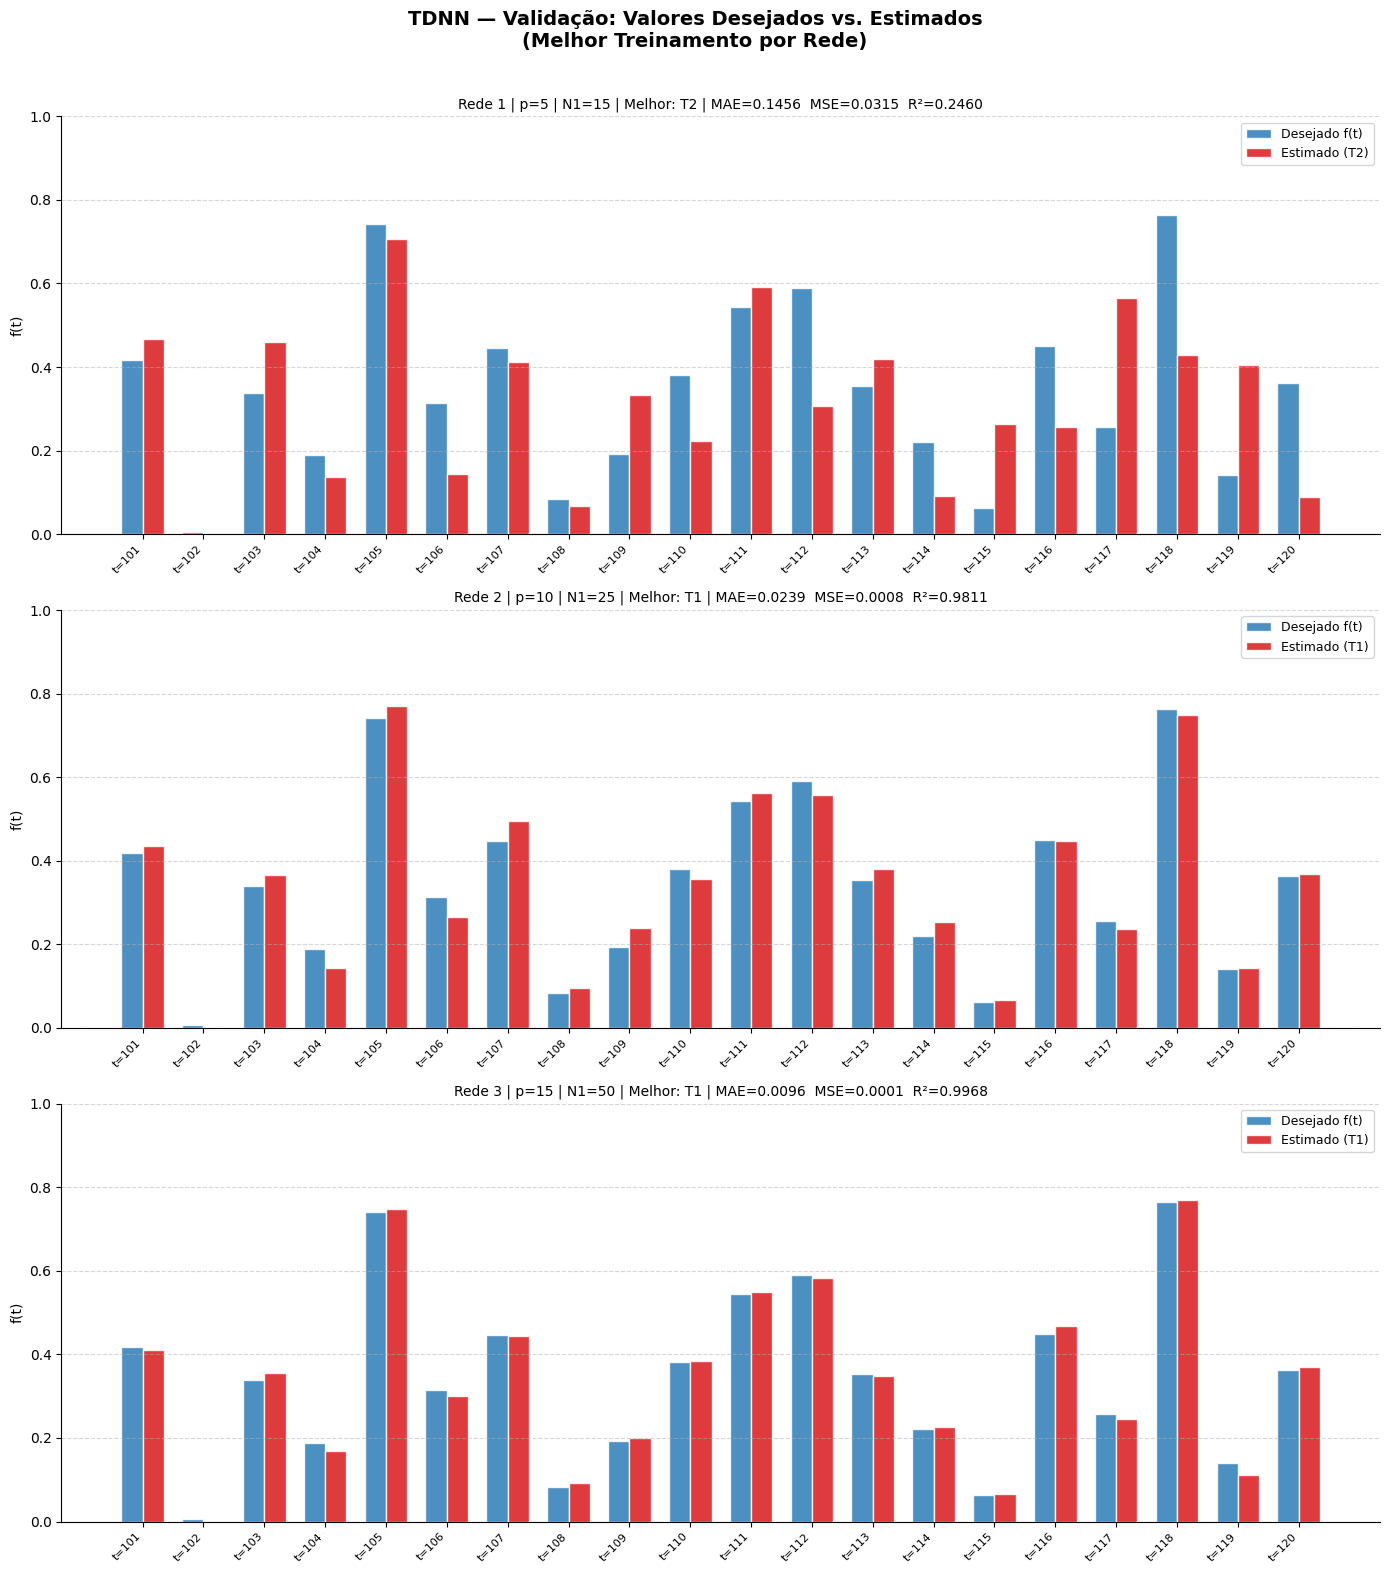


  Figura salva como 'tdnn_resultado.png'

SUMÁRIO FINAL

  Rede 1:
Treino     Loss  Épocas
    T1 0.001024    2396
    T2 0.002258     919
    T3 0.001564     417

  Rede 2:
Treino     Loss  Épocas
    T1 0.000268    1755
    T2 0.019747      55
    T3 0.000441     279

  Rede 3:
Treino     Loss  Épocas
    T1 0.000023    1414
    T2 0.025921      42
    T3 0.000036     610

  Solver utilizado: adam

  Fim do exercício TDNN.


In [ ]:
# ITEM 1 — Rede 1 com solver='sgd'
print("=" * 60)
print("ITEM 1 — Rede 1 | solver=sgd")
print("=" * 60)

p1 = redes['Rede 1']['p']
N1 = redes['Rede 1']['N1']

X_train_1, y_train_1 = build_tdnn_dataset(train_data, p1)

mlp_sgd = MLPRegressor(
    hidden_layer_sizes=(N1,),
    activation='relu',
    solver='sgd',
    max_iter=5000,
    tol=1e-6,
    momentum=0.9,
    early_stopping=True,
    epsilon=1e-6,
    learning_rate_init=0.001,
    learning_rate='constant',
    random_state=42
)

mlp_sgd.fit(X_train_1, y_train_1)

print(f"  Loss final (SGD) : {mlp_sgd.loss_:.6f}")
print(f"  Épocas           : {mlp_sgd.n_iter_}")

seed_sgd = train_data[-p1:]
pred_sgd = predict_iterative(mlp_sgd, seed_sgd, n_steps=20)

mae_sgd = mean_absolute_error(y_test_real, pred_sgd)
mse_sgd = mean_squared_error(y_test_real, pred_sgd)
r2_sgd  = r2_score(y_test_real, pred_sgd)

print(f"\n  Validação no conjunto de teste (t=101..120):")
print(f"  MAE  : {mae_sgd:.4f}")
print(f"  MSE  : {mse_sgd:.4f}")
print(f"  R²   : {r2_sgd:.4f}")

# ITEM 2 — Rede 1 com solver='adam' (comparação)
print()
print("=" * 60)
print("ITEM 2 — Rede 1 | solver=adam  (comparação com SGD)")
print("=" * 60)

mlp_adam = MLPRegressor(
    hidden_layer_sizes=(N1,),
    activation='relu',
    solver='adam',
    max_iter=5000,
    tol=1e-6,
    early_stopping=True,
    epsilon=1e-6,
    learning_rate_init=0.001,
    random_state=42
)

mlp_adam.fit(X_train_1, y_train_1)

print(f"  Loss final (Adam): {mlp_adam.loss_:.6f}")
print(f"  Épocas           : {mlp_adam.n_iter_}")

seed_adam = train_data[-p1:]
pred_adam = predict_iterative(mlp_adam, seed_adam, n_steps=20)

mae_adam = mean_absolute_error(y_test_real, pred_adam)
mse_adam = mean_squared_error(y_test_real, pred_adam)
r2_adam  = r2_score(y_test_real, pred_adam)

print(f"\n  Validação no conjunto de teste (t=101..120):")
print(f"  MAE  : {mae_adam:.4f}")
print(f"  MSE  : {mse_adam:.4f}")
print(f"  R²   : {r2_adam:.4f}")

print()
print("  *** COMENTÁRIO — Item 2 ***")
print("  O solver Adam utiliza estimativas adaptativas de momentos de")
print("  primeira e segunda ordem para ajustar a taxa de aprendizado")
print("  individualmente por parâmetro. Em geral converge mais rápido")
print("  (menos épocas) e tende a alcançar menor loss em séries como")
print("  esta, enquanto o SGD com momentum fixo pode precisar de mais")
print("  épocas ou ficar preso em mínimos locais. Nota: no MLPRegressor")
print("  do sklearn, o Adam não usa os parâmetros momentum e")
print("  learning_rate='constant', pois gerencia a lr internamente.")


# ITEM 3 — 3 treinamentos para cada rede com o melhor solver
print()
print("=" * 60)
print("ITEM 3 — 3 treinamentos por rede | solver=adam")
print("=" * 60)

# Escolha: solver='adam' (melhor desempenho observado no Item 2)
BEST_SOLVER = 'adam'

# Estrutura para guardar modelos e resultados
results_item3 = {}   # results_item3[nome_rede][t] = (model, loss, epochs)
pred_item4    = {}   # pred_item4[nome_rede][t]    = array de predições (20 valores)

tabela_item3 = []

for nome_rede, cfg in redes.items():
    p  = cfg['p']
    n1 = cfg['N1']

    X_tr, y_tr = build_tdnn_dataset(train_data, p)
    seed_win   = train_data[-p:]

    results_item3[nome_rede] = {}
    pred_item4[nome_rede]    = {}

    print(f"\n  {nome_rede} | p={p} | N1={n1}")
    print(f"  {'Treino':<10} {'Loss':>12} {'Épocas':>8}")
    print(f"  {'-'*32}")

    for t_idx in range(1, 4):
        mlp = MLPRegressor(
            hidden_layer_sizes=(n1,),
            activation='relu',
            solver=BEST_SOLVER,
            max_iter=5000,
            tol=1e-6,
            early_stopping=True,
            epsilon=1e-6,
            learning_rate_init=0.001
            # sem random_state => pesos aleatórios a cada execução
        )
        mlp.fit(X_tr, y_tr)

        loss   = mlp.loss_
        epochs = mlp.n_iter_

        results_item3[nome_rede][t_idx] = (mlp, loss, epochs)

        # Predição iterativa para t=101..120
        preds = predict_iterative(mlp, seed_win, n_steps=20)
        pred_item4[nome_rede][t_idx] = preds

        print(f"  T{t_idx:<9} {loss:>12.6f} {epochs:>8}")
        tabela_item3.append({
            'Rede': nome_rede, 'Treino': f'T{t_idx}',
            'Loss': round(loss, 6), 'Épocas': epochs
        })

print()
print("  Solver utilizado nos 3 treinamentos:", BEST_SOLVER)


# ITEM 4 — Validação: MAE, MSE, R² para cada treinamento
print()
print("=" * 60)
print("ITEM 4 — Validação (MAE, MSE, R²) — t=101..120")
print("=" * 60)

amostras_teste = list(range(101, 121))

for nome_rede in redes:
    print(f"\n  {nome_rede}")
    print(f"  {'Amostra':>8} {'f(t)':>8}", end='')
    for t_idx in range(1, 4):
        print(f"  {'T'+str(t_idx):>10}", end='')
    print()

    for i, amostra in enumerate(amostras_teste):
        fval = y_test_real[i]
        print(f"  t={amostra:>5} {fval:>8.4f}", end='')
        for t_idx in range(1, 4):
            pval = pred_item4[nome_rede][t_idx][i]
            print(f"  {pval:>10.4f}", end='')
        print()

    print(f"\n  {'Métrica':<25}", end='')
    for t_idx in range(1, 4):
        print(f"  {'T'+str(t_idx):>10}", end='')
    print()

    for metrica_nome, func in [('MAE', mean_absolute_error),
                                ('MSE', mean_squared_error),
                                ('R² Score', r2_score)]:
        print(f"  {metrica_nome:<25}", end='')
        for t_idx in range(1, 4):
            val = func(y_test_real, pred_item4[nome_rede][t_idx])
            print(f"  {val:>10.4f}", end='')
        print()


# ITEM 5 — Gráficos de barras: melhor treinamento por rede
print()
print("=" * 60)
print("ITEM 5 — Gráficos de barras do melhor treinamento por rede")
print("=" * 60)

def melhor_treino(nome_rede):
    """Retorna o índice do treino com menor MAE."""
    maes = {
        t_idx: mean_absolute_error(y_test_real, pred_item4[nome_rede][t_idx])
        for t_idx in range(1, 4)
    }
    return min(maes, key=maes.get)

fig, axes = plt.subplots(3, 1, figsize=(14, 16))
fig.suptitle('TDNN — Validação: Valores Desejados vs. Estimados\n(Melhor Treinamento por Rede)',
             fontsize=14, fontweight='bold', y=0.98)

cores_desejado  = '#2c7bb6'
cores_estimado  = '#d7191c'
largura_barra   = 0.35

for ax, (nome_rede, cfg) in zip(axes, redes.items()):
    best_t = melhor_treino(nome_rede)
    preds  = pred_item4[nome_rede][best_t]

    mae_b = mean_absolute_error(y_test_real, preds)
    mse_b = mean_squared_error(y_test_real, preds)
    r2_b  = r2_score(y_test_real, preds)

    x = np.arange(len(amostras_teste))

    bars1 = ax.bar(x - largura_barra / 2, y_test_real, largura_barra,
                   label='Desejado f(t)', color=cores_desejado, alpha=0.85, edgecolor='white')
    bars2 = ax.bar(x + largura_barra / 2, preds, largura_barra,
                   label=f'Estimado (T{best_t})', color=cores_estimado, alpha=0.85, edgecolor='white')

    ax.set_xticks(x)
    ax.set_xticklabels([f't={a}' for a in amostras_teste], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('f(t)', fontsize=10)
    ax.set_title(
        f'{nome_rede} | p={cfg["p"]} | N1={cfg["N1"]} | Melhor: T{best_t} | '
        f'MAE={mae_b:.4f}  MSE={mse_b:.4f}  R²={r2_b:.4f}',
        fontsize=10
    )
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1.0)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    print(f"  {nome_rede} — Melhor treino: T{best_t} | "
          f"MAE={mae_b:.4f} | MSE={mse_b:.4f} | R²={r2_b:.4f}")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('tdnn_resultado.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n  Figura salva como 'tdnn_resultado.png'")


# SUMÁRIO FINAL
print()
print("=" * 60)
print("SUMÁRIO FINAL")
print("=" * 60)

df_tabela = pd.DataFrame(tabela_item3)
for nome_rede in redes:
    print(f"\n  {nome_rede}:")
    subset = df_tabela[df_tabela['Rede'] == nome_rede][['Treino','Loss','Épocas']]
    print(subset.to_string(index=False))

print(f"\n  Solver utilizado: {BEST_SOLVER}")
print()
print("  Fim do exercício TDNN.")